In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Second Term NTU/Artificial_Perception/Lecture_6

/content/drive/MyDrive/Second Term NTU/Artificial_Perception/Lecture_6


# Lab 6 - Speech Perception

In this lab you will:

1. Load a small multi-speaker speech dataset
2. Compare two speech-to-text systems:
   - PocketSphinx (a classical approach)
   - OpenAI Whisper (an end-to-end approach)
3. Measure accuracy and inference time between the two
4. Run a robustness experiment by introducing noise
5. Perform keyword detection from transcripts
6. Perform speaker identification using speaker embeddings
7. Apply what you have learnt to unseen audio clips

Today, we are going to use a small subset of the **VCTK dataset**.

The subset of data is available in this week's NOW learning room, and all data is contained within the "VCTK-small" folder.

Read more about the dataset and related project here - https://datashare.ed.ac.uk/handle/10283/2950



> Veaux, C., Yamagishi, J. and King, S., 2013, November. The voice bank corpus: Design, collection and data analysis of a large regional accent speech database. In 2013 international conference oriental COCOSDA held jointly with 2013 conference on Asian spoken language research and evaluation (O-COCOSDA/CASLRE) (pp. 1-4). IEEE.



In [ ]:
!unzip VCTK-small.zip # if you are using Google Colab

unzip:  cannot find or open VCTK-small.zip, VCTK-small.zip.zip or VCTK-small.zip.ZIP.


First, we will install and import the required libraries

In [ ]:
!pip -q install librosa soundfile pocketsphinx transformers accelerate jiwer

import os, re, time, random
from pathlib import Path
import numpy as np
import librosa
import soundfile as sf
import torch
import torchaudio
from transformers import pipeline
from pocketsphinx import Decoder, get_model_path

RNG = 42
random.seed(RNG)
np.random.seed(RNG)
torch.manual_seed(RNG)

print("Torch:", torch.__version__)
print("Torchaudio:", torchaudio.__version__)
print("CUDA available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.2/29.2 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 80.2 MB/s eta 0:00:00
Torch: 2.9.0+cpu
Torchaudio: 2.9.0+cpu
CUDA available: False


Let's quickly check the contents of the dataset...

**Note:** in the original dataset, spoken line 7 is missing for Speaker_03 (227 in the original dataset)

In [ ]:
ROOT = Path("VCTK-small")

assert ROOT.exists(), (
    "Could not find VCTK-small/. "
)

speaker_dirs = sorted([p for p in ROOT.iterdir() if p.is_dir() and p.name.startswith("Speaker_")])
print("Speakers:", [p.name for p in speaker_dirs])

for sd in speaker_dirs:
    wavs = sorted(sd.glob("*.wav"))
    txts = sorted(sd.glob("*.txt"))
    print(f"{sd.name}: {len(wavs)} wav, {len(txts)} txt")

Speakers: ['Speaker_01', 'Speaker_02', 'Speaker_03', 'Speaker_04']
Speaker_01: 10 wav, 10 txt
Speaker_02: 10 wav, 10 txt
Speaker_03: 9 wav, 9 txt
Speaker_04: 10 wav, 10 txt


Below, I have written some helper functions to calculate the error rate of each model.

Here, we define similarity as the ratio of similarity between two strings.

In [ ]:
def normalise_text(s: str) -> str:
    #switch to lower case
    s = s.lower().strip()
    # remove everything except letters and spaces
    s = re.sub(r"[^a-z\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

from difflib import SequenceMatcher

def similarity(ref: str, hyp: str) -> float:
    ref_n = normalise_text(ref)
    hyp_n = normalise_text(hyp)
    return SequenceMatcher(None, ref_n, hyp_n).ratio()

Now let's load our dataset. Since we have the transcriptions for each .wav file, we have paired data.

This means we can compare the transcription to the ground truth by calculating the similarity between them.

In [ ]:
ROOT = Path("VCTK-small")
assert ROOT.exists(), "Could not find the VCTK-small/ folder"

speaker_dirs = sorted([p for p in ROOT.iterdir() if p.is_dir() and p.name.startswith("Speaker_")])

print("Speakers:", [p.name for p in speaker_dirs])

def load_pairs(speaker_dir: Path):
    pairs = []
    for wav_path in sorted(speaker_dir.glob("*.wav")):
        txt_path = wav_path.with_suffix(".txt")
        assert txt_path.exists(), f"Missing transcript for {wav_path.name}"
        ref = txt_path.read_text(encoding="utf-8").strip()
        pairs.append((wav_path, ref))
    return pairs

dataset = []
for sd in speaker_dirs:
    for wav_path, ref in load_pairs(sd):
        dataset.append({
            "speaker_dir": sd.name,
            "wav": wav_path,
            "ref": ref
        })

print("Total paired clips:", len(dataset))
print("Example:", dataset[0]["wav"].name, " Transcription: \"", dataset[0]["ref"], "\"")

Speakers: ['Speaker_01', 'Speaker_02', 'Speaker_03', 'Speaker_04']
Total paired clips: 39
Example: p225_001.wav  Transcription: " Please call Stella. "


Before moving on, we will inspect one of the files...

**Point of Reflection**: is the below format time-domain or frequency-domain?

File: VCTK-small/Speaker_01/p225_001.wav
Speaker folder: Speaker_01
Transcript: Please call Stella.
Audio length (s): 2.05 | SR: 16000


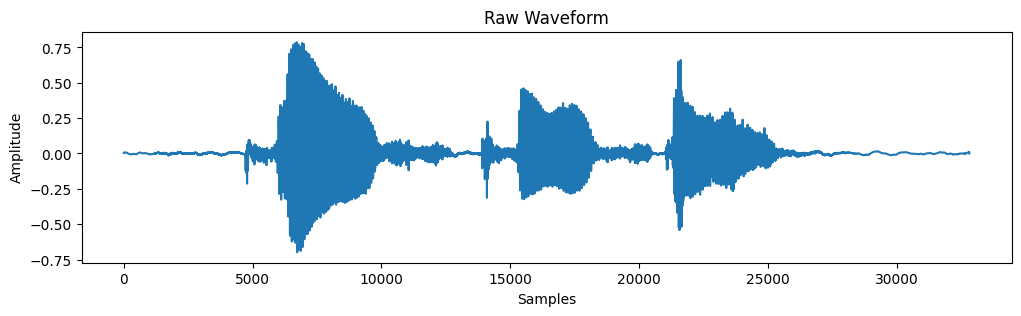

In [ ]:
example = dataset[0]
print("File:", example["wav"])
print("Speaker folder:", example["speaker_dir"])
print("Transcript:", example["ref"])

y, sr = librosa.load(example["wav"], sr=16000, mono=True)
print("Audio length (s):", round(len(y)/sr, 2), "| SR:", sr)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 3))
plt.plot(y)
plt.title("Raw Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

from IPython.display import Audio, display
display(Audio(example["wav"], autoplay=False))

**Reflection:** if you kept the above code as-is (Speaker_01 saying "Please call Stella.") take a look at the raw waveform. Note that the words "Please" and "Stella" are well-defined. However, the word "call" takes on two distinct patterns.  

In [ ]:
!pip -q install vosk
!wget -q https://alphacephei.com/vosk/models/vosk-model-small-en-us-0.15.zip
!unzip -q vosk-model-small-en-us-0.15.zip


replace vosk-model-small-en-us-0.15/am/final.mdl? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import json
from vosk import Model, KaldiRecognizer

VOSK_MODEL_DIR = "vosk-model-small-en-us-0.15"
vosk_model = Model(VOSK_MODEL_DIR)

def transcribe_vosk(wav_path: Path) -> str:
    y, sr = librosa.load(wav_path, sr=16000, mono=True)
    tmp_wav = Path("/tmp/vosk_tmp.wav")
    sf.write(tmp_wav, y, 16000, subtype="PCM_16")

    rec = KaldiRecognizer(vosk_model, 16000)
    rec.SetWords(False)

    with open(tmp_wav, "rb") as f:
        while True:
            data = f.read(4000)
            if len(data) == 0:
                break
            rec.AcceptWaveform(data)

    result = json.loads(rec.FinalResult())
    return result.get("text", "").strip()

print("Testing from Example audio clip\n")
print("Ground truth:", example["ref"])
stt_test = transcribe_vosk(example["wav"])
print("Transcribed:", stt_test)

norm_stt_test = normalise_text(stt_test)
norm_truth = normalise_text(example["ref"])

score = similarity(norm_truth, norm_stt_test)
print("Similarity", score, "\n")

score = '{0:.2f}'.format(score*100)
print("There was a ", score, "% match!")

Testing from Example audio clip

Ground truth: Please call Stella.
Transcribed: please call stellar
Similarity 0.972972972972973 

There was a  97.30 % match!


Now let's download OpenAI Whisper before testing it on the same audio.

**Note:** we are using the small Whisper model ("small"). There are larger Whisper models available that perform much better!

See the Whisper models available here: https://github.com/openai/whisper

In [ ]:
!pip install git+https://github.com/openai/whisper.git
!apt-get -qq install ffmpeg

  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-ryui3wrd
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-ryui3wrd
  Resolved https://github.com/openai/whisper.git to commit c0d2f624c09dc18e709e37c2ad90c039a4eb72a2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 3.2 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803980 sha256=3e0929e84d6445982a463f958983775c6bbe837f06cb896fbe46d1e65ca4e42b
  Stored in directory: /tmp/pip-ephem-wheel-cache-e920qa4x/wheels/c3/03/25/5e0ba78bc27a3a089f137c9f1d92fdfce16d06996c071a016c
Successfully built openai-whisper


In [ ]:
import whisper

whisper_model = whisper.load_model("small.en")

def transcribe_whisper(wav_path: Path) -> str:
    result = whisper_model.transcribe(
        str(wav_path),
        fp16=torch.cuda.is_available() # only use 16 bit precision if a GPU is available
    )
    return result["text"].strip()

100%|███████████████████████████████████████| 461M/461M [00:11<00:00, 43.8MiB/s]


# Testing both models

We will now test both models on the example audio file. The below code checks the similarity between the ground truth and transcription. We also record how long it takes, with more complex models taking longer.

Note: if you are using GPU acceleration, Whisper will run much quicker.

In [ ]:
import time

print("Testing from Example audio clip\n")
print("Ground truth:", example["ref"])
print("\n -- VOSK model (classical)")
vosk_start = time.time()
stt_test = transcribe_vosk(example["wav"])
vosk_end = time.time()
print("Transcribed:", stt_test)

norm_stt_test = normalise_text(stt_test)
norm_truth = normalise_text(example["ref"])

score = similarity(norm_truth, norm_stt_test)
print("Similarity", score, "\n")

score = '{0:.2f}'.format(score*100)
print("There was a ", score, "% match!")
vosk_time = vosk_end - vosk_start
print("Time taken:", vosk_time, "seconds")

print("\n -- OpenAI Whisper Model (end-to-end)")
whisper_start = time.time()
stt_test = transcribe_whisper(example["wav"])
whisper_end = time.time()
print("Transcribed:", stt_test)

norm_stt_test = normalise_text(stt_test)
norm_truth = normalise_text(example["ref"])

score = similarity(norm_truth, norm_stt_test)
print("Similarity", score, "\n")

score = '{0:.2f}'.format(score*100)
print("There was a ", score, "% match!")
whisper_time = whisper_end - whisper_start
print("Time taken:", whisper_time, "seconds")

Testing from Example audio clip

Ground truth: Please call Stella.

 -- VOSK model (classical)
Transcribed: please call stellar
Similarity 0.972972972972973 

There was a  97.30 % match!
Time taken: 1.6614539623260498 seconds

 -- OpenAI Whisper Model (end-to-end)
Transcribed: Please call Stella.
Similarity 1.0 

There was a  100.00 % match!
Time taken: 21.489291429519653 seconds


# Let's make it more challenging for the models...

We are going to add some synthetic noise to the audio and see what happens. This will help us to test how robust they are with lower quality audio.

In [ ]:
def save_audio_file(y, sr=16000, filename="tmp.wav"):
    y = np.clip(y, -1.0, 1.0)
    sf.write(filename, y, sr, subtype="PCM_16")
    return Path(filename)

def add_noise(y, snr_db=5.0):
    signal_power = np.mean(y**2) + 1e-12
    snr_linear = 10**(snr_db/10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), size=y.shape)
    return y + noise

y, sr = librosa.load(example["wav"], sr=16000, mono=True)
noisy = add_noise(y, snr_db=5.0)
noisy_path = save_audio_file(noisy, 16000, "noisy.wav")
display(Audio(noisy_path, autoplay=False))


print("Testing from NOISY audio clip\n")
print("Ground truth:", example["ref"])
print("\n -- VOSK model (classical)")
vosk_start = time.time()
stt_test = transcribe_vosk(noisy_path)
vosk_end = time.time()
print("Transcribed:", stt_test)

norm_stt_test = normalise_text(stt_test)
norm_truth = normalise_text(example["ref"])

score = similarity(norm_truth, norm_stt_test)
print("Similarity", score, "\n")

score = '{0:.2f}'.format(score*100)
print("There was a ", score, "% match!")
vosk_time = vosk_end - vosk_start
print("Time taken:", vosk_time, "seconds")

print("\n -- OpenAI Whisper Model (end-to-end)")
whisper_start = time.time()
stt_test = transcribe_whisper(noisy_path)
whisper_end = time.time()
print("Transcribed:", stt_test)

norm_stt_test = normalise_text(stt_test)
norm_truth = normalise_text(example["ref"])

score = similarity(norm_truth, norm_stt_test)
print("Similarity", score, "\n")

score = '{0:.2f}'.format(score*100)
print("There was a ", score, "% match!")
whisper_time = whisper_end - whisper_start
print("Time taken:", whisper_time, "seconds")

Testing from NOISY audio clip

Ground truth: Please call Stella.

 -- VOSK model (classical)
Transcribed: nice fella
Similarity 0.42857142857142855 

There was a  42.86 % match!
Time taken: 2.093461751937866 seconds

 -- OpenAI Whisper Model (end-to-end)
Transcribed: Please call Stella.
Similarity 1.0 

There was a  100.00 % match!
Time taken: 15.932549953460693 seconds


# Challenge 1 - Transcribing the **whole** dataset

Now let's take our dataset and see which approach performs best.

In the below skeleton code, the function loops through each audio file.

At the moment, scores and times are given as zero.

Your challenge: study the previous examples, and then use this to write code for transcription and timing for both Vosk and Whisper.

**Point of reflection**: which model scored best, on average? Is there a tradeoff between transcription ability and computational complexity?

In [ ]:
vosk_scores = []
whisper_scores = []

vosk_times = []
whisper_times = []

print("Testing on all data...\n")
for item in dataset:
    print("Working on... ", item["wav"])
    wav_path = item["wav"]
    ref_text = item["ref"]

    # Transcribe with Vosk and append the score/time
    # TODO here
    '''vosk_score = 0
    vosk_time = 0
    vosk_scores.append(vosk_score)
    vosk_times.append(vosk_time)''' #edited out

    # VOSK TRANSCRIPTION
    vosk_start = time.time()
    vosk_hyp = transcribe_vosk(wav_path)
    vosk_end = time.time()

    vosk_hyp_norm = normalise_text(vosk_hyp)
    ref_norm = normalise_text(ref_text)
    vosk_score = similarity(ref_norm, vosk_hyp_norm)
    vosk_time = vosk_end - vosk_start

    vosk_scores.append(vosk_score)
    vosk_times.append(vosk_time)

    # Transcribe with Whisper and append the score/time
    '''whisper_score = 0
    whisper_time = 0
    whisper_scores.append(whisper_score)
    whisper_times.append(whisper_time)'''# edited out

    # WHISPER TRANSCRIPTION
    # ---------------------------
    whisper_start = time.time()
    whisper_hyp = transcribe_whisper(wav_path)
    whisper_end = time.time()

    whisper_hyp_norm = normalise_text(whisper_hyp)
    whisper_score = similarity(ref_norm, whisper_hyp_norm)
    whisper_time = whisper_end - whisper_start

    whisper_scores.append(whisper_score)
    whisper_times.append(whisper_time)

    print("Done.")


print("\nExperiments finished!")

print("Vosk average similarity:", np.mean(vosk_scores))
print("Vosk average time (s):", np.mean(vosk_times))

print("Whisper average similarity:", np.mean(whisper_scores))
print("Whisper average time (s):", np.mean(whisper_times))

Testing on all data...

Working on...  VCTK-small/Speaker_01/p225_001.wav
Done.
Working on...  VCTK-small/Speaker_01/p225_002.wav
Done.
Working on...  VCTK-small/Speaker_01/p225_003.wav
Done.
Working on...  VCTK-small/Speaker_01/p225_004.wav
Done.
Working on...  VCTK-small/Speaker_01/p225_005.wav
Done.
Working on...  VCTK-small/Speaker_01/p225_006.wav
Done.
Working on...  VCTK-small/Speaker_01/p225_007.wav
Done.
Working on...  VCTK-small/Speaker_01/p225_008.wav
Done.
Working on...  VCTK-small/Speaker_01/p225_009.wav
Done.
Working on...  VCTK-small/Speaker_01/p225_010.wav
Done.
Working on...  VCTK-small/Speaker_02/p226_001.wav
Done.
Working on...  VCTK-small/Speaker_02/p226_002.wav
Done.
Working on...  VCTK-small/Speaker_02/p226_003.wav
Done.
Working on...  VCTK-small/Speaker_02/p226_004.wav
Done.
Working on...  VCTK-small/Speaker_02/p226_005.wav
Done.
Working on...  VCTK-small/Speaker_02/p226_006.wav
Done.
Working on...  VCTK-small/Speaker_02/p226_007.wav
Done.
Working on...  VCTK-smal

# Challenge 2 - Keyword Detection

Following your previous challenge, now let's try keyword detection. Below is some skeleton code that shows:
1.   Detecting the word "Alexa" within a string
2.   Extracting the command that came after "Alexa"

Following that, the same loop as above is available which goes through each of the audio files in our dataset.

**Your Challenge**: For each of the audio files, try to detect the keyword **"Please"**, using both Vosk and Whisper.


In [ ]:
example_transcription = "I think I will cook dinner in a little while. Alexa, set a timer to go off in ten minutes to preheat the oven."
keyword = "Alexa"

example_transcription = normalise_text(example_transcription)
keyword = normalise_text(keyword)

print(example_transcription, "\n")
if keyword in example_transcription:
    print("Keyword found:", keyword)
    instruction = example_transcription.split(keyword, 1)[1].strip()
    print("Instruction:", instruction)
else:
    print("Keyword not detected.")


# End of example - make changes below...
print("\n------\n")

keyword = "Please"
keyword = normalise_text(keyword)

print("Testing on all data...\n")
for item in dataset:
    print("Searching in... ", item["wav"])
    wav_path = item["wav"]

    #TODO: transcribe the text from the audio
    # --- Vosk transcription ---
    transcription = transcribe_vosk(wav_path)

    # --- Whisper transcription ---
    # transcription = transcribe_whisper(wav_path)

    transcription = normalise_text(transcription)

    if keyword in transcription:
      print("Keyword found:", keyword)
      instruction = transcription.split(keyword, 1)[1].strip()
      print("Instruction:", instruction, "\n")
    else:
      print("Keyword not detected.\n")

i think i will cook dinner in a little while alexa set a timer to go off in ten minutes to preheat the oven 

Keyword found: alexa
Instruction: set a timer to go off in ten minutes to preheat the oven

------

Testing on all data...

Searching in...  VCTK-small/Speaker_01/p225_001.wav
Keyword found: please
Instruction: call stellar 

Searching in...  VCTK-small/Speaker_01/p225_002.wav
Keyword not detected.

Searching in...  VCTK-small/Speaker_01/p225_003.wav
Keyword not detected.

Searching in...  VCTK-small/Speaker_01/p225_004.wav
Keyword not detected.

Searching in...  VCTK-small/Speaker_01/p225_005.wav
Keyword not detected.

Searching in...  VCTK-small/Speaker_01/p225_006.wav
Keyword not detected.

Searching in...  VCTK-small/Speaker_01/p225_007.wav
Keyword not detected.

Searching in...  VCTK-small/Speaker_01/p225_008.wav
Keyword not detected.

Searching in...  VCTK-small/Speaker_01/p225_009.wav
Keyword not detected.

Searching in...  VCTK-small/Speaker_01/p225_010.wav
Keyword not 

# Stretch Task
If you want an additional challenge, repeat the experiment with **noisy** audio.

Some tips:
1.   Start by replicating the transcription challenge.
2.   Before transcribing the audio, add noise using the provided function and save it as a temporary file.
3.   Transcribe the temporary file with both Vosk and Whisper.
4.   Record the average score for each model and compare them to the non-noisy audio.

Similarly to earlier, reflect on the tradeoff between robustness and computational complexity.

---

**Further challenge:**
For a further challenge, we had complete trust in our models for keyword detection... but this isn't quite right.

We did not account for the model detecting the keyword by mistake (a false positive). For example, the phrase *"with dinner, I'll have peas and carrots"* could be misheard as *"**please** and carrots"* - our device would therefore start listening to the user without being commanded to.

To check for errors, compare the transcription to the ground truth to double check that the detection of the word "please" was not a **false positive**.


In [ ]:
# write your code here!

In [ ]:
# ==== STRETCH TASK A: Transcription on NOISY audio ====
# Uses: add_noise(), save_audio_file(), transcribe_vosk(), transcribe_whisper(), normalise_text(), similarity(), dataset
# From lab: add_noise and save_audio_file were already defined above.  [1](https://myntuac-my.sharepoint.com/personal/n1419979_my_ntu_ac_uk/Documents/Microsoft%20Copilot%20Chat%20Files/Lab_6.pdf)

noisy_vosk_scores = []
noisy_whisper_scores = []
noisy_vosk_times = []
noisy_whisper_times = []

SNR_DB = 5.0  # you can try 0, 5, 10 to see robustness across noise levels

print(f"Testing on NOISY data (SNR = {SNR_DB} dB)...\n")

for item in dataset:
    wav_path = item["wav"]
    ref_text = normalise_text(item["ref"])

    # 1) Load clean audio
    y, sr = librosa.load(wav_path, sr=16000, mono=True)

    # 2) Inject noise and save a temporary file
    noisy_y = add_noise(y, snr_db=SNR_DB)
    noisy_path = save_audio_file(noisy_y, 16000, filename="tmp_noisy.wav")

    # ---------------------------
    # VOSK on noisy
    # ---------------------------
    vosk_start = time.time()
    noisy_vosk_hyp = transcribe_vosk(noisy_path)
    vosk_end = time.time()

    noisy_vosk_score = similarity(ref_text, normalise_text(noisy_vosk_hyp))
    noisy_vosk_time = vosk_end - vosk_start

    noisy_vosk_scores.append(noisy_vosk_score)
    noisy_vosk_times.append(noisy_vosk_time)

    # ---------------------------
    # WHISPER on noisy
    # ---------------------------
    whisper_start = time.time()
    noisy_whisper_hyp = transcribe_whisper(noisy_path)
    whisper_end = time.time()

    noisy_whisper_score = similarity(ref_text, normalise_text(noisy_whisper_hyp))
    noisy_whisper_time = whisper_end - whisper_start

    noisy_whisper_scores.append(noisy_whisper_score)
    noisy_whisper_times.append(noisy_whisper_time)

print("\nNoisy experiments finished!\n")

print("NOISY - Vosk average similarity:", np.mean(noisy_vosk_scores))
print("NOISY - Vosk average time (s):", np.mean(noisy_vosk_times))

print("NOISY - Whisper average similarity:", np.mean(noisy_whisper_scores))
print("NOISY - Whisper average time (s):", np.mean(noisy_whisper_times))

Testing on NOISY data (SNR = 5.0 dB)...


Noisy experiments finished!

NOISY - Vosk average similarity: 0.7874666516041519
NOISY - Vosk average time (s): 2.739573142467401
NOISY - Whisper average similarity: 0.9780214009873316
NOISY - Whisper average time (s): 9.867823655788715


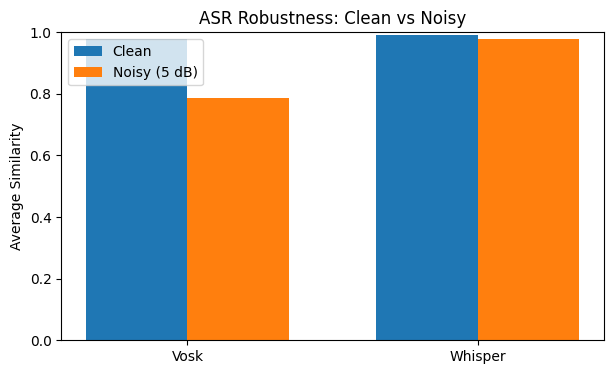

In [ ]:
# OPTIONAL: quick bar plot for clean vs noisy (requires that you ran Challenge 1 earlier)
import matplotlib.pyplot as plt

labels = ['Vosk', 'Whisper']
clean_scores = [np.mean(vosk_scores), np.mean(whisper_scores)]
noisy_scores = [np.mean(noisy_vosk_scores), np.mean(noisy_whisper_scores)]

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - w/2, clean_scores, width=w, label='Clean')
plt.bar(x + w/2, noisy_scores, width=w, label='Noisy (5 dB)')
plt.ylim(0, 1.0)
plt.ylabel('Average Similarity')
plt.title('ASR Robustness: Clean vs Noisy')
plt.xticks(x, labels)
plt.legend()
plt.show()


In [ ]:
# ==== STRETCH TASK B: Keyword "please" with FALSE-POSITIVE CONTROL ====
# Uses: transcribe_whisper() or transcribe_vosk(), normalise_text(), similarity(), dataset  [1](https://myntuac-my.sharepoint.com/personal/n1419979_my_ntu_ac_uk/Documents/Microsoft%20Copilot%20Chat%20Files/Lab_6.pdf)

keyword = "please"
print("\nFALSE-POSITIVE-CONTROLLED keyword detection\n")

# Tunable parameters
WINDOW_SIZE = 3        # number of words before/after the keyword to compare
SIM_THRESHOLD = 0.65   # similarity threshold for local-window confirmation

def extract_window(words, idx, window=3):
    start = max(0, idx - window)
    end = min(len(words), idx + window + 1)
    return " ".join(words[start:end])

def find_all_indices(words, target):
    return [i for i, w in enumerate(words) if w == target]

tp = 0   # true positives (keyword truly present)
fp = 0   # false positives (model heard "please" but ref doesn't support it)
fn = 0   # false negatives (keyword in ref but model missed it)

for item in dataset:
    wav_path = item["wav"]
    ref_text_raw = item["ref"]

    # 1) Transcribe (choose model)
    hyp_text_raw = transcribe_whisper(wav_path)
    # If you want Vosk instead, comment the line above and uncomment below:
    # hyp_text_raw = transcribe_vosk(wav_path)

    # 2) Normalize both
    ref_text = normalise_text(ref_text_raw)
    hyp_text = normalise_text(hyp_text_raw)

    ref_words = ref_text.split()
    hyp_words = hyp_text.split()

    hyp_has_kw = keyword in hyp_words
    ref_has_kw = keyword in ref_words

    if hyp_has_kw:
        # 3) Local-window verification for each detected "please" in hyp
        hyp_indices = find_all_indices(hyp_words, keyword)

        # Attempt to align each hyp window with the closest spot in ref that also contains keyword
        # If ref doesn't have keyword at all, mark as FP immediately
        if not ref_has_kw:
            fp += 1
            print(f"[FP] {wav_path.name}: hyp has '{keyword}', ref does NOT.")
            continue

        ref_indices = find_all_indices(ref_words, keyword)

        # Compute best window similarity between any hyp keyword window and any ref keyword window
        best_sim = 0.0
        for hi in hyp_indices:
            hyp_win = extract_window(hyp_words, hi, WINDOW_SIZE)
            for ri in ref_indices:
                ref_win = extract_window(ref_words, ri, WINDOW_SIZE)
                win_sim = similarity(ref_win, hyp_win)
                if win_sim > best_sim:
                    best_sim = win_sim

        if best_sim >= SIM_THRESHOLD:
            tp += 1
            print(f"[TP] {wav_path.name}: keyword confirmed (local sim={best_sim:.2f})")
        else:
            fp += 1
            print(f"[FP] {wav_path.name}: keyword mismatch (best local sim={best_sim:.2f})")

    else:
        # Model did not detect keyword; if reference contains it, count as FN
        if ref_has_kw:
            fn += 1
            print(f"[FN] {wav_path.name}: keyword present in ref but MISSED by model.")
        else:
            print(f"[OK] {wav_path.name}: keyword absent in both hyp and ref.")

# Simple metrics for the keyword detector with FP control
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

print("\n---- Keyword Detection (with FP control) ----")
print("True Positives:", tp)
print("False Positives:", fp)
print("False Negatives:", fn)
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")


FALSE-POSITIVE-CONTROLLED keyword detection

[TP] p225_001.wav: keyword confirmed (local sim=1.00)
[OK] p225_002.wav: keyword absent in both hyp and ref.
[OK] p225_003.wav: keyword absent in both hyp and ref.
[OK] p225_004.wav: keyword absent in both hyp and ref.
[OK] p225_005.wav: keyword absent in both hyp and ref.
[OK] p225_006.wav: keyword absent in both hyp and ref.
[OK] p225_007.wav: keyword absent in both hyp and ref.
[OK] p225_008.wav: keyword absent in both hyp and ref.
[OK] p225_009.wav: keyword absent in both hyp and ref.
[OK] p225_010.wav: keyword absent in both hyp and ref.
[TP] p226_001.wav: keyword confirmed (local sim=1.00)
[OK] p226_002.wav: keyword absent in both hyp and ref.
[OK] p226_003.wav: keyword absent in both hyp and ref.
[OK] p226_004.wav: keyword absent in both hyp and ref.
[OK] p226_005.wav: keyword absent in both hyp and ref.
[OK] p226_006.wav: keyword absent in both hyp and ref.
[OK] p226_007.wav: keyword absent in both hyp and ref.
[OK] p226_008.wav: ke